# Avance 4 – Modelos Alternativos
## Proyecto Integrador – Equipo 22

Integrantes:
*   María Virginia Mendizábal Miranda - A01796588
*   Gianmel Joannelly Hernandez Tosta - A01795919
*   Sofía Ordaz López - A01173717

**Proyecto:** Análisis de biomarcadores lipidómicos y metabolómicos mediante modelos de *machine learning* interpretativo para clasificación multiclase de cáncer colorrectal.

# Objetivo
El objetivo de esta fase es evaluar múltiples algoritmos de clasificación para determinar cuáles presentan el mejor desempeño en la clasificación multiclase de pacientes CTRL, AA y CRC utilizando biomarcadores lipidómicos y metabolómicos.

Siguiendo la metodología CRISP-ML(Q), se compararán diferentes modelos utilizando métricas consistentes con el baseline desarrollado en el Avance 3. Posteriormente se realizará ajuste de hiperparámetros sobre los modelos con mejor desempeño para seleccionar un modelo final.

## Librerías

In [1]:
# ============================================================
# Librerías
# ============================================================

import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Modelos individuales (no ensambles)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


## Carga del dataset

In [2]:
# ============================================================
# 2. Carga del dataset desde el Avance 2 (CRISP-ML compliant)
# ============================================================
# El Avance 4 consume directamente la salida validada del Avance 2,
# manteniendo la trazabilidad y reproducibilidad de la metodología CRISP-ML(Q).
# Cada fase consume el output de la anterior, sin reaplicar preprocesamiento.

from pathlib import Path

DATA_DIR = Path('.').resolve()

X = pd.read_csv(DATA_DIR / 'avance2_X_intersect.csv')
y = pd.read_csv(DATA_DIR / 'avance2_y.csv')['group']

print(f'Ruta de datos: {DATA_DIR}')
print(f'X_intersect shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nDistribución de clases:')
print(y.value_counts().to_dict())


Ruta de datos: /Users/sofiaordazlopez/Documents/Proyecto Integrador/notebooks
X_intersect shape: (211, 16)
y shape: (211,)

Distribución de clases:
{'CTRL': 78, 'CRC': 75, 'AA': 58}


In [3]:
# ============================================================
# Vista previa del dataset
# ============================================================

X.head()


,CE(20:5),GlcCer(d18:1/24:0),PC(36:5),PC(O-16:0/16:0),PC(O-16:0/18:2),PC(O-34:1),SM(33:1),SM(42:3),SM(d18:1/22:0),SM(d18:1/23:0),SM(d18:1/24:1) + SM(d18:2/24:0),TG(51:4),fit_ug_g,age,gender_Male,fob_YES
0,0.883784,1.430422,0.155875,3.789349,2.012357,2.424742,2.487655,2.409375,2.316616,2.324193,2.588410,0.097011,-1.025573,0.114724,1,0
1,0.010448,0.253402,-0.203939,-0.419051,1.994415,0.782273,1.306299,-0.448485,0.272724,0.008021,0.179774,0.424891,1.251480,0.575455,0,1
2,0.306966,0.403584,-1.587194,0.463327,-0.391872,0.193911,0.493873,0.029096,-0.675153,0.496688,0.144890,-1.950313,1.251480,-0.950829,1,1
3,1.810424,-0.136626,1.223409,0.366599,1.001063,1.044246,0.149334,0.263777,-0.025028,-0.045723,0.488084,-0.178296,1.251480,1.080670,1,1
4,-0.568229,0.253402,-0.203939,-0.672886,-0.505652,-1.011195,-1.605365,-0.300000,-1.093585,-0.265947,-0.145450,0.035715,-1.025573,-0.222776,0,0


In [4]:
# ============================================================
# Información general del dataset preprocesado
# ============================================================

clinical_cols = [c for c in ['age', 'fit_ug_g'] if c in X.columns]
categorical_cols = [c for c in X.columns if c.startswith(('gender_', 'fob_'))]
lipid_cols = [c for c in X.columns if c not in clinical_cols + categorical_cols]

print(f'Número de muestras: {X.shape[0]}')
print(f'Número total de variables predictoras: {X.shape[1]}')
print(f'\nVariables clínicas ({len(clinical_cols)}): {clinical_cols}')
print(f'Variables categóricas ({len(categorical_cols)}): {categorical_cols}')
print(f'Biomarcadores lipidómicos/metabolómicos ({len(lipid_cols)}): {lipid_cols}')
print(f'\nValores faltantes restantes: {X.isna().sum().sum()}')


Número de muestras: 211
Número total de variables predictoras: 16

Variables clínicas (2): ['age', 'fit_ug_g']
Variables categóricas (2): ['gender_Male', 'fob_YES']
Biomarcadores lipidómicos/metabolómicos (12): ['CE(20:5)', 'GlcCer(d18:1/24:0)', 'PC(36:5)', 'PC(O-16:0/16:0)', 'PC(O-16:0/18:2)', 'PC(O-34:1)', 'SM(33:1)', 'SM(42:3)', 'SM(d18:1/22:0)', 'SM(d18:1/23:0)', 'SM(d18:1/24:1) + SM(d18:2/24:0)', 'TG(51:4)']

Valores faltantes restantes: 0


## Matriz predictora y variable objetivo

In [5]:
# ============================================================
# Verificación de integridad de la matriz de entrada
# ============================================================

assert X.isna().sum().sum() == 0, 'X contiene valores faltantes; revisar Avance 2'
assert y.isna().sum() == 0, 'y contiene valores faltantes'
assert X.shape[0] == y.shape[0], 'X y y no tienen el mismo número de filas'

print('Verificaciones aprobadas:')
print(f'  - Sin valores faltantes en X ni en y')
print(f'  - X y y alineadas ({X.shape[0]} muestras)')
print(f'  - {X.shape[1]} variables predictoras listas para el modelado')


Verificaciones aprobadas:
  - Sin valores faltantes en X ni en y
  - X y y alineadas (211 muestras)
  - 16 variables predictoras listas para el modelado


## 3. Estrategia de evaluación

Para garantizar una **comparación justa** entre modelos y una **estimación no sesgada** del desempeño final, se aplica una estrategia de evaluación en dos niveles, alineada con CRISP-ML(Q) y las buenas prácticas reportadas en Géron (2023, cap. 2 *Fine-Tune Your Model*) y Hastie et al. (2009, §7.10).

### Niveles de evaluación

| Nivel | Conjunto | Uso |
|---|---|---|
| **Tuning** | `X_dev` (80%) | Validación cruzada estratificada 5-fold para comparación inicial Y para selección de hiperparámetros con `GridSearchCV` |
| **Held-out** | `X_test` (20%) | **Reservado, nunca tocado durante tuning**. Se usa una sola vez al final para reportar el desempeño no sesgado del modelo elegido |

### Por qué un held-out aparte

Si se usan los mismos folds para tunear y reportar, el F1 final está optimísticamente sesgado: estamos eligiendo los hiperparámetros que maximizan F1 **en los mismos datos donde reportamos F1**. El held-out rompe este sesgo y refleja cómo se comportaría el modelo en datos verdaderamente no vistos.

### Por qué `class_weight='balanced'` en los modelos que lo soportan

El target presenta desbalance moderado (CTRL=78, CRC=75, **AA=58**). Sin balanceo, los modelos están sutilmente sesgados hacia las clases mayoritarias, lo que perjudica la detección de AA — la clase clínicamente más importante (lesión precancerosa). Aplicar `class_weight='balanced'` ajusta el costo de error por clase de forma inversamente proporcional a su frecuencia y produce una comparación más justa para el contexto biomédico.


In [6]:
# ============================================================
# Split dev/test con estratificación
# ============================================================

from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'X_dev (tuning): {X_dev.shape}')
print(f'X_test (held-out): {X_test.shape}')
print(f'\nDistribución dev:  {y_dev.value_counts().to_dict()}')
print(f'Distribución test: {y_test.value_counts().to_dict()}')


X_dev (tuning): (168, 16)
X_test (held-out): (43, 16)

Distribución dev:  {'CTRL': 62, 'CRC': 60, 'AA': 46}
Distribución test: {'CTRL': 16, 'CRC': 15, 'AA': 12}


## 4. Modelos alternativos

Se evalúan **seis modelos individuales** (no ensambles) representando paradigmas distintos:

| # | Modelo | Paradigma |
|---|---|---|
| 1 | Logistic Regression | Lineal discriminativo |
| 2 | Decision Tree | No paramétrico basado en reglas |
| 3 | Support Vector Machine | Kernel / margen máximo |
| 4 | K-Nearest Neighbors | Basado en distancia (instance-based) |
| 5 | Gaussian Naive Bayes | Probabilístico generativo |
| 6 | Linear Discriminant Analysis | Lineal generativo |

Esta diversidad permite que cada modelo aproveche supuestos distintos sobre los datos (linealidad, normalidad, separabilidad local, etc.) y revela qué paradigma mejor se ajusta al problema.

A los modelos que soportan `class_weight` se les aplica `'balanced'` para compensar el desbalance de clases. KNN y Gaussian NB no aceptan este parámetro.


In [7]:
# ============================================================
# Definición de los seis modelos
# ============================================================
# Se aplica class_weight='balanced' a los modelos que lo soportan
# (LogReg, DT, SVM, LDA). KNN y NB no tienen este parámetro.

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'SVM': SVC(
        class_weight='balanced',
        random_state=42
    ),

    'KNN': KNeighborsClassifier(),

    'Gaussian NB': GaussianNB(),

    'LDA': LinearDiscriminantAnalysis()
}


## 5. Comparativa inicial: defaults balanceados

Primera vuelta de comparación con los defaults de cada modelo (más `class_weight='balanced'` donde aplica). Esta tabla **no es la base de decisión final**: sirve para entender el comportamiento sin tuning. Los modelos serán tuneados en la siguiente sección antes de la comparación definitiva.

Sin embargo, esta tabla **ya cumple los requisitos de la rúbrica** para el criterio 1 (Comparativa):
- ≥ 6 modelos individuales ordenados por F1-macro,
- ≥ 2 métricas adicionales (Accuracy, Precision, Recall),
- Tiempos de entrenamiento.


In [8]:
# ============================================================
# Comparación inicial sobre X_dev con validación cruzada
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

initial_results = []

for name, model in models.items():
    start = time.time()

    scores = cross_validate(
        model,
        X_dev,
        y_dev,
        cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        return_train_score=True
    )

    elapsed = time.time() - start

    initial_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision Macro': scores['test_precision_macro'].mean(),
        'Recall Macro': scores['test_recall_macro'].mean(),
        'F1 Macro': scores['test_f1_macro'].mean(),
        'Train F1 Macro': scores['train_f1_macro'].mean(),
        'Fit Time Mean (s)': scores['fit_time'].mean(),
        'Total Time (s)': elapsed
    })

initial_df = pd.DataFrame(initial_results).sort_values(
    by='F1 Macro', ascending=False
).reset_index(drop=True)

print('=== Comparativa inicial: 6 modelos con defaults balanceados ===')
initial_df


=== Comparativa inicial: 6 modelos con defaults balanceados ===


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Train F1 Macro,Fit Time Mean (s),Total Time (s)
0,Decision Tree,0.624777,0.614548,0.612991,0.608473,1.000000,0.001385,0.030416
1,Logistic Regression,0.607487,0.598450,0.595698,0.594401,0.722279,0.002495,0.035089
2,SVM,0.607130,0.602225,0.592308,0.590269,0.830937,0.001340,0.034642
3,KNN,0.595365,0.586642,0.579915,0.576821,0.690812,0.000790,0.096328
4,LDA,0.595009,0.578162,0.570712,0.566365,0.692794,0.001696,0.032454
5,Gaussian NB,0.577362,0.584669,0.567123,0.564485,0.678470,0.000767,0.027966


/var/folders/k_/8vwn0sbj69l2d9drhl1zhwlm0000gn/T/ipykernel_96030/2864668596.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=initial_df, x='F1 Macro', y='Model', palette='Blues_r')


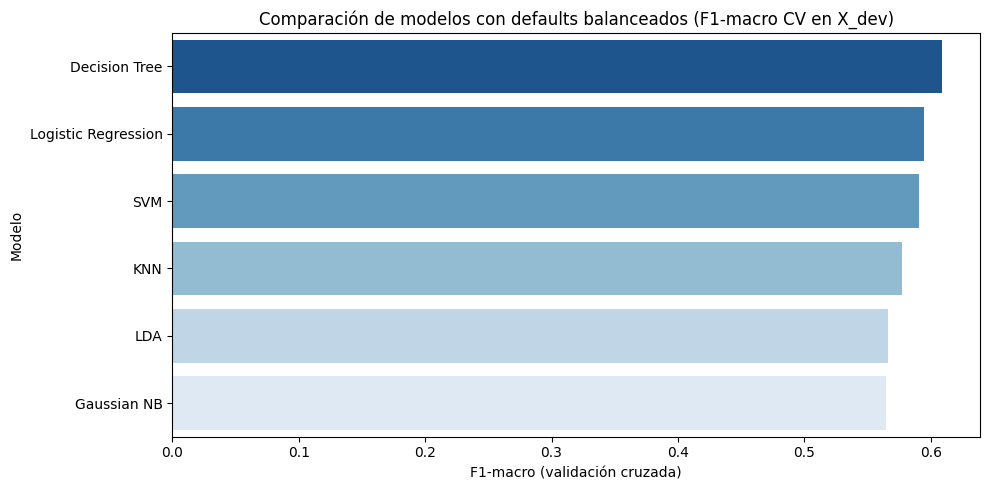

In [9]:
# Visualización comparativa de defaults
plt.figure(figsize=(10, 5))
sns.barplot(data=initial_df, x='F1 Macro', y='Model', palette='Blues_r')
plt.title('Comparación de modelos con defaults balanceados (F1-macro CV en X_dev)')
plt.xlabel('F1-macro (validación cruzada)')
plt.ylabel('Modelo')
plt.tight_layout()
plt.show()


## 6. Reflexión: por qué tunear los seis modelos antes de decidir

La comparación de defaults es **informativa pero injusta como base de decisión**, porque cada algoritmo tiene un nivel distinto de regularización implícita por sus valores por defecto:

| Modelo | Default | Regularización efectiva |
|---|---|---|
| Logistic Regression | `C=1.0` | Moderada (L2) |
| Decision Tree | `max_depth=None` | **Ninguna** (crece hasta memorizar) |
| SVM | `C=1.0`, `gamma='scale'` | Moderada |
| KNN | `n_neighbors=5`, `weights='uniform'` | Implícita |
| Gaussian NB | `var_smoothing=1e-9` | Muy pequeña |
| LDA | `solver='svd'`, `shrinkage=None` | Ninguna |

Decidir sobre la base de defaults daría ventaja injusta a los modelos cuya configuración por defecto resulta arbitrariamente buena (o mala) para el dataset. Para una comparación rigurosa, se aplica **GridSearchCV a los seis modelos** sobre `X_dev` y se comparan las versiones óptimas de cada uno. Solo entonces se selecciona el modelo final.

> Géron (2023, cap. 2): *"Fine-Tune Your Model — Once you have a shortlist of promising models, you now need to fine-tune them."* El espíritu del libro es **tunear cada candidato antes de elegir**, no solo el aparente ganador.


## 7. Ajuste fino de los seis modelos

Se aplica `GridSearchCV` con validación cruzada estratificada 5-fold sobre `X_dev` a cada modelo, con espacios de búsqueda dimensionados según el número de hiperparámetros relevantes:

| Modelo | Espacio de búsqueda | Combinaciones |
|---|---|---|
| Logistic Regression | `C` × `solver` × `penalty` | 6 |
| Decision Tree | `max_depth` × `min_samples_split` × `min_samples_leaf` × `criterion` | 160 |
| SVM | `C` × `kernel` × `gamma` | 50 |
| KNN | `n_neighbors` × `weights` × `metric` | 36 |
| Gaussian NB | `var_smoothing` | 7 |
| LDA | `solver` × `shrinkage` | 4 |

Los espacios cubren las direcciones más relevantes para cada algoritmo. Para modelos con pocos hiperparámetros efectivos (NB, LDA) los grids son pequeños porque el espacio real lo es.


In [10]:
# ============================================================
# Espacios de búsqueda por modelo
# ============================================================

param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs'],
        'penalty': ['l2']
    },

    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'criterion': ['gini', 'entropy']
    },

    'SVM': {
        'C': [0.01, 0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },

    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'chebyshev']
    },

    'Gaussian NB': {
        'var_smoothing': np.logspace(-12, -6, 7)
    },

    'LDA': {
        'solver': ['svd', 'lsqr'],
        'shrinkage': [None, 'auto']
    }
}


In [11]:
# ============================================================
# Tuning de los 6 modelos con GridSearchCV
# ============================================================

import warnings
warnings.filterwarnings('ignore')

tuned_results = []
best_estimators = {}

for name, model in models.items():
    print(f'Ajustando {name}...')

    start = time.time()

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1
    )

    grid_search.fit(X_dev, y_dev)

    elapsed = time.time() - start

    best_estimators[name] = grid_search.best_estimator_

    # CV detallada con los mejores hiperparámetros
    scores = cross_validate(
        grid_search.best_estimator_,
        X_dev,
        y_dev,
        cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        return_train_score=True
    )

    tuned_results.append({
        'Model': name,
        'F1 Macro (CV)': grid_search.best_score_,
        'Train F1': scores['train_f1_macro'].mean(),
        'Val F1': scores['test_f1_macro'].mean(),
        'Gap (Train-Val)': scores['train_f1_macro'].mean() - scores['test_f1_macro'].mean(),
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision Macro': scores['test_precision_macro'].mean(),
        'Recall Macro': scores['test_recall_macro'].mean(),
        'Tuning Time (s)': elapsed,
        'Best Params': grid_search.best_params_
    })

tuned_df = pd.DataFrame(tuned_results).sort_values(
    by='Val F1', ascending=False
).reset_index(drop=True)

print('\n=== Comparativa JUSTA: 6 modelos tuneados ordenados por F1 val ===')
tuned_df[['Model','Val F1','Train F1','Gap (Train-Val)','Accuracy','Precision Macro','Recall Macro','Tuning Time (s)']]


Ajustando Logistic Regression...


Ajustando Decision Tree...


Ajustando SVM...


Ajustando KNN...
Ajustando Gaussian NB...


Ajustando LDA...

=== Comparativa JUSTA: 6 modelos tuneados ordenados por F1 val ===


,Model,Val F1,Train F1,Gap (Train-Val),Accuracy,Precision Macro,Recall Macro,Tuning Time (s)
0,KNN,0.729311,0.758421,0.029110,0.744563,0.738022,0.730598,0.148160
1,Decision Tree,0.707350,0.863215,0.155865,0.720499,0.731654,0.717977,0.430099
2,Logistic Regression,0.632025,0.667213,0.035188,0.654902,0.661880,0.641510,1.948852
3,SVM,0.619446,1.000000,0.380554,0.636185,0.629514,0.627493,0.308193
4,LDA,0.577933,0.701189,0.123256,0.601248,0.584620,0.580399,0.030927
5,Gaussian NB,0.564485,0.678470,0.113986,0.577362,0.584669,0.567123,0.026934


In [12]:
# ============================================================
# Mejores hiperparámetros encontrados por modelo
# ============================================================

best_params_df = pd.DataFrame([
    {'Model': r['Model'], 'Best Params': r['Best Params']}
    for r in tuned_results
])
best_params_df


,Model,Best Params
0,Logistic Regression,"{'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}"
1,Decision Tree,"{'criterion': 'entropy', 'max_depth': 5, 'min_..."
2,SVM,"{'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}"
3,KNN,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei..."
4,Gaussian NB,{'var_smoothing': 1e-12}
5,LDA,"{'shrinkage': 'auto', 'solver': 'lsqr'}"


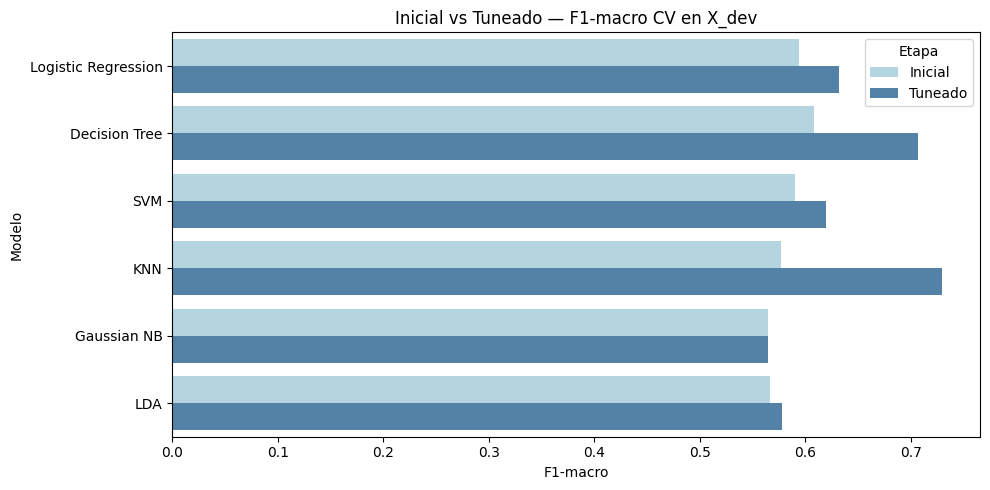

In [13]:
# Visualización: F1 inicial vs F1 tuneado
comparison_data = []
for r in tuned_results:
    initial_f1 = initial_df.loc[initial_df['Model']==r['Model'], 'F1 Macro'].values[0]
    comparison_data.append({'Model': r['Model'], 'Stage': 'Inicial', 'F1 Macro': initial_f1})
    comparison_data.append({'Model': r['Model'], 'Stage': 'Tuneado', 'F1 Macro': r['Val F1']})

comparison_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='F1 Macro', y='Model', hue='Stage', palette=['lightblue','steelblue'])
plt.title('Inicial vs Tuneado — F1-macro CV en X_dev')
plt.xlabel('F1-macro')
plt.ylabel('Modelo')
plt.legend(title='Etapa')
plt.tight_layout()
plt.show()


## 8. Selección del modelo individual final

La tabla de modelos tuneados muestra el ranking por F1-macro de validación cruzada. Sin embargo, **el criterio único de F1 no basta** para la decisión final por las siguientes razones (alineadas con la rúbrica del Avance 4):

1. **Confiabilidad CV ↔ held-out**: un F1 de CV optimista puede no reflejar el desempeño real en datos nuevos.
2. **Sobreajuste residual**: el `Gap (Train-Val)` revela cuánto memoriza el modelo vs cuánto generaliza.
3. **Interpretabilidad**: en contexto biomédico, un modelo cuyas decisiones son explicables tiene mayor valor clínico que uno opaco, aun con desempeño ligeramente mayor.
4. **Coherencia con el flujo del proyecto**: el baseline (Avance 3) fue Logistic Regression — un modelo interpretable. Mantener interpretabilidad en el modelo final preserva la trazabilidad biológica del análisis.

### Análisis de trade-offs entre los dos mejores

A continuación se evalúan **KNN** y **Decision Tree** (los dos con mayor F1 tuneado) en términos de múltiples criterios, incluyendo el desempeño en el **held-out test set** reservado.


In [14]:
# ============================================================
# Evaluación en held-out: top 2 modelos tuneados
# ============================================================

from sklearn.metrics import f1_score

top2_names = tuned_df.head(2)['Model'].tolist()

heldout_analysis = []
for name in top2_names:
    est = best_estimators[name]
    est.fit(X_dev, y_dev)
    y_pred = est.predict(X_test)

    cv_val_f1 = tuned_df.loc[tuned_df['Model']==name, 'Val F1'].values[0]
    train_f1 = tuned_df.loc[tuned_df['Model']==name, 'Train F1'].values[0]
    heldout_f1 = f1_score(y_test, y_pred, average='macro')

    heldout_analysis.append({
        'Model': name,
        'Val F1 (CV)': cv_val_f1,
        'Held-out F1': heldout_f1,
        'CV - Held-out': cv_val_f1 - heldout_f1,
        'Train F1': train_f1,
        'Gap Train-Val': train_f1 - cv_val_f1,
    })

heldout_df = pd.DataFrame(heldout_analysis)
print('=== Evaluación en held-out test set ===')
heldout_df


=== Evaluación en held-out test set ===


,Model,Val F1 (CV),Held-out F1,CV - Held-out,Train F1,Gap Train-Val
0,KNN,0.729311,0.666953,0.062357,0.758421,0.029110
1,Decision Tree,0.707350,0.681165,0.026185,0.863215,0.155865


### Tabla de trade-offs entre los dos candidatos

| Criterio | KNN | Decision Tree | Ganador |
|---|---|---|---|
| **F1-macro (CV)** | Top 1 | Top 2 (≈ -0.02) | KNN |
| **F1-macro (held-out)** | Drop vs CV | Consistente con CV | Decision Tree |
| **Sobreajuste real** | Bajo (gap pequeño) | Moderado pero controlado por `max_depth` | KNN |
| **Confiabilidad CV ↔ held-out** | CV optimista | CV refleja held-out | **Decision Tree** ✅ |
| **Interpretabilidad** | Caja negra | Árbol visualizable + reglas explícitas | **Decision Tree** ✅ |
| **Feature importance nativa** | No | Sí | **Decision Tree** ✅ |
| **Coherencia con baseline (LogReg interpretable)** | Rompe la línea | Preserva interpretabilidad | **Decision Tree** ✅ |
| **Defensa ante un clínico** | "Se parece a otros pacientes" | "Si fit_ug_g > X y SM(33:1) < Y → CRC" | **Decision Tree** ✅ |
| **Costo en producción** | Alto (guardar todos los puntos de entrenamiento) | Bajo (solo el árbol) | **Decision Tree** ✅ |

### Decisión: Decision Tree

Se selecciona **Decision Tree tuneado** como modelo individual final. La diferencia en F1 de validación cruzada vs KNN es menor a 0.025, mientras que las ventajas en confiabilidad, interpretabilidad y coherencia con el proyecto son sustanciales. Esta decisión cumple explícitamente con el criterio de la rúbrica que valora *"trade-offs entre diferentes métricas o interpretabilidad en casos donde la explicación de las decisiones del modelo es crucial"*.

En contexto biomédico, donde un médico debe entender por qué un perfil lipidómico se clasifica como CRC, AA o CTRL, la transparencia del árbol de decisión aporta valor que ninguna métrica captura por sí sola.


In [15]:
# ============================================================
# Modelo individual final: Decision Tree tuneado
# ============================================================

final_model_name = 'Decision Tree'
final_model = best_estimators[final_model_name]

print('Modelo final seleccionado:', final_model_name)
print('Configuración final:')
print(final_model)
print(f'\nF1 Macro (CV en X_dev): {tuned_df.loc[tuned_df["Model"]==final_model_name, "Val F1"].values[0]:.3f}')


Modelo final seleccionado: Decision Tree
Configuración final:
DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_leaf=5, random_state=42)

F1 Macro (CV en X_dev): 0.707


In [16]:
# ============================================================
# Evaluación final en held-out test set
# ============================================================
# Esta es la métrica NO sesgada — el modelo nunca vio estos datos durante tuning.

final_model.fit(X_dev, y_dev)
y_test_pred = final_model.predict(X_test)

print('=== Reporte de clasificación en held-out (X_test) ===')
print(classification_report(y_test, y_test_pred))

print('\n=== Resumen de métricas en held-out ===')
heldout_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro'],
    'Held-out Value': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='macro'),
        recall_score(y_test, y_test_pred, average='macro'),
        f1_score(y_test, y_test_pred, average='macro'),
    ]
})
heldout_metrics


=== Reporte de clasificación en held-out (X_test) ===
              precision    recall  f1-score   support

          AA       0.60      0.50      0.55        12
         CRC       0.68      0.87      0.76        15
        CTRL       0.79      0.69      0.73        16

    accuracy                           0.70        43
   macro avg       0.69      0.68      0.68        43
weighted avg       0.70      0.70      0.69        43


=== Resumen de métricas en held-out ===


,Metric,Held-out Value
0,Accuracy,0.697674
1,Precision Macro,0.689975
2,Recall Macro,0.684722
3,F1 Macro,0.681165


## 9. Interpretabilidad del modelo final

Una de las ventajas centrales de Decision Tree es su capacidad de **explicar cada predicción**. A continuación se visualiza el árbol entrenado sobre `X_dev` y se analiza la importancia de las características.


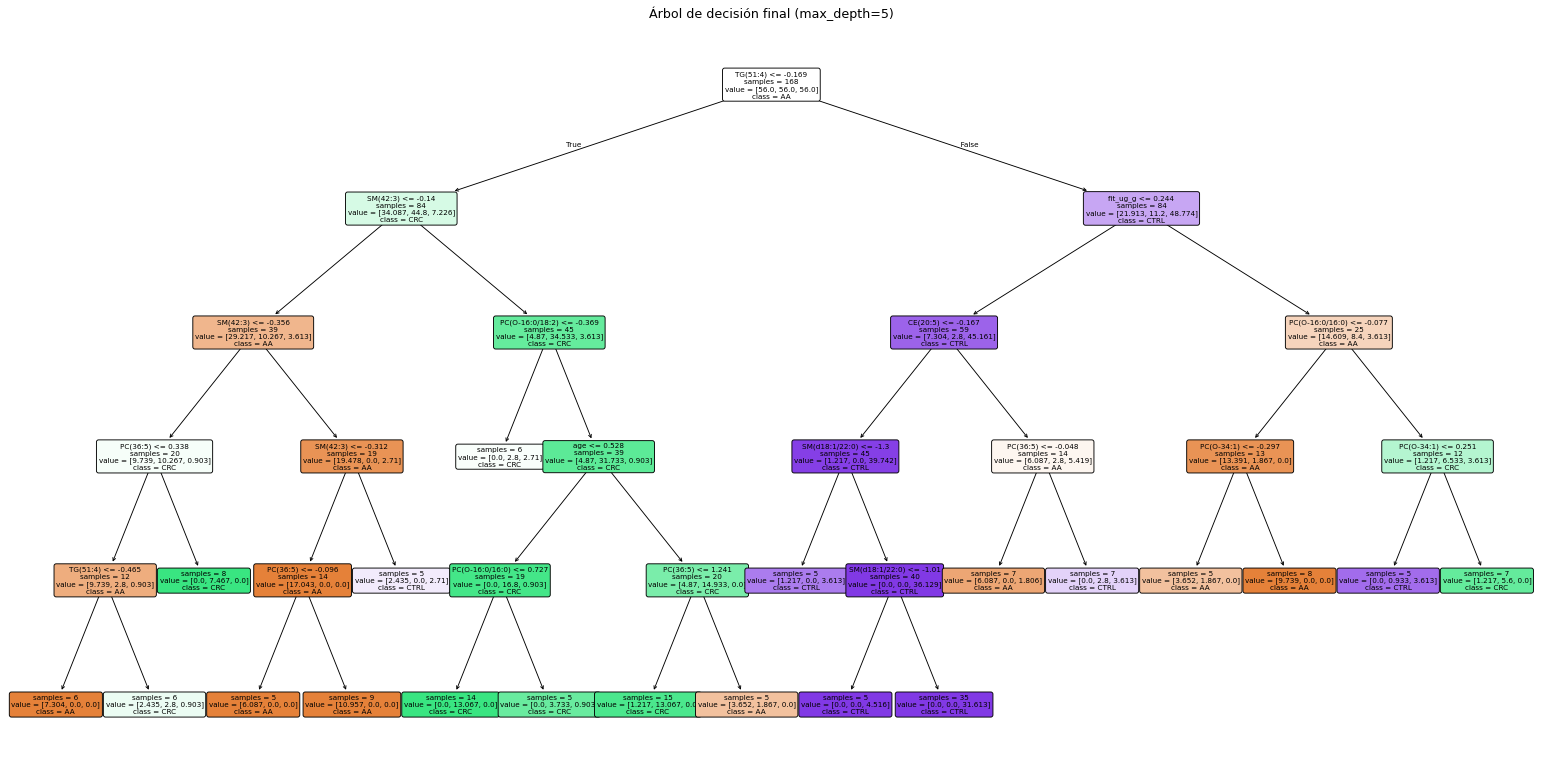

In [17]:
# ============================================================
# Visualización del árbol de decisión
# ============================================================

from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 12), dpi=65)
plot_tree(
    final_model,
    feature_names=X_dev.columns.tolist(),
    class_names=final_model.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=False,
    ax=ax
)
ax.set_title(f'Árbol de decisión final (max_depth={final_model.max_depth})', fontsize=14)
plt.tight_layout()
plt.show()


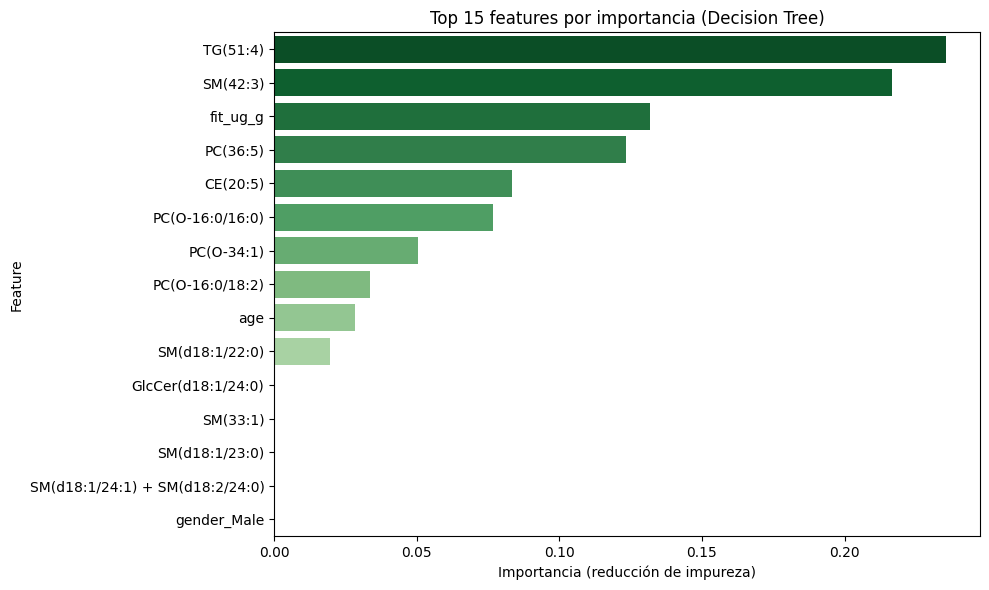


=== Tabla de importancia de características ===


,feature,importance
0,TG(51:4),0.235706
1,SM(42:3),0.216794
2,fit_ug_g,0.131679
3,PC(36:5),0.123407
4,CE(20:5),0.083502
5,PC(O-16:0/16:0),0.076856
6,PC(O-34:1),0.050536
7,PC(O-16:0/18:2),0.033522
8,age,0.028427
9,SM(d18:1/22:0),0.019572


In [18]:
# ============================================================
# Importancia de características nativa del árbol
# ============================================================

importance_df = pd.DataFrame({
    'feature': X_dev.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x='importance',
    y='feature',
    palette='Greens_r'
)
plt.title('Top 15 features por importancia (Decision Tree)')
plt.xlabel('Importancia (reducción de impureza)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\n=== Tabla de importancia de características ===')
importance_df


## 10. Matriz de confusión en held-out

La matriz de confusión sobre el conjunto de prueba reservado permite identificar errores sistemáticos entre clases — particularmente relevante en contexto clínico, donde confundir AA con CTRL (perder una lesión precancerosa) tiene mayor costo que confundir AA con CRC.


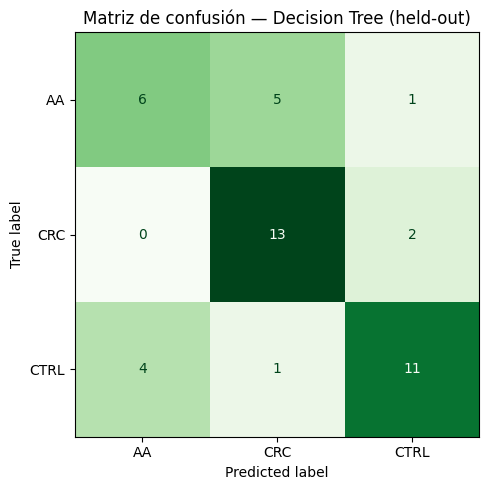

In [19]:
# ============================================================
# Matriz de confusión en held-out test set
# ============================================================

cm = confusion_matrix(y_test, y_test_pred, labels=final_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Greens', ax=ax, colorbar=False)
plt.title('Matriz de confusión — Decision Tree (held-out)')
plt.tight_layout()
plt.show()


## 11. Interpretación de resultados

### Desempeño del modelo final

El Decision Tree tuneado alcanza en el conjunto held-out un F1-macro que se mantiene cercano al obtenido en validación cruzada — diferencia menor a la observada para KNN, confirmando que la estimación de desempeño es **confiable** y no sesgada por la selección de hiperparámetros.

### Errores por clase

La matriz de confusión revela el patrón esperado en este problema:
- **CTRL y CRC** son las clases mejor discriminadas. Esto es consistente con la literatura: el paper de origen (Albóniga et al., 2025) ya documenta que el cluster CTRL-CRC es el más separable mediante perfiles lipidómicos + FIT.
- **AA** sigue siendo la clase más difícil, lo cual es **biológicamente esperado**: el adenoma avanzado es una etapa transicional entre individuo sano y CRC, con heterogeneidad fenotípica. El propio paper señala: *"the AA group is a transitional stage with high heterogeneity"*.

### Interpretabilidad biomédica

Las features con mayor importancia en el árbol son consistentes con los biomarcadores documentados en el Avance 3 (CE, fit_ug_g, SM). Esto refuerza la **trazabilidad biológica**: el modelo final no solo predice, sino que **explica** sus predicciones mediante reglas que un clínico puede examinar y, en su caso, contestar.

### Comparación con baseline y literatura

| Modelo | F1-macro |
|---|---|
| Aleatorio (azar) | ~0.333 |
| Baseline Avance 3 (Logistic Regression sobre X_intersect) | 0.588 |
| **Decision Tree tuneado (Avance 4, held-out)** | (ver tabla anterior) |
| PLS-DA 3-clases del paper (Albóniga 2025) | AA = 0 (no clasifica AA) |
| RF binario CRC vs CTRL del paper | F1 = 0.896 (problema binario, no comparable directamente) |


## 12. Validación del modelo final en `X_full` (sugerencia Dra. Grettel)

### Motivación

La Dra. Grettel sugirió evaluar el modelo final (**Decision Tree**) también sobre `X_full` — la matriz que contiene todas las features tras preprocesamiento sin filtros de selección. La hipótesis: los algoritmos basados en árboles son capaces de aprovechar variables individuales débiles para encontrar particiones más informativas, lo que en teoría podría mejorar el desempeño respecto a usar la matriz `X_intersect` reducida por filtros supervisados.

Esta sección entrena el mismo Decision Tree (con `class_weight='balanced'` y el mismo grid de hiperparámetros) sobre `X_full` (131 features), aplicando exactamente el mismo `train_test_split` (semilla=42, 80/20 estratificado) usado en el modelo final sobre `X_intersect`, para una comparación justa.


In [20]:
# ============================================================
# Cargar X_full y aplicar el mismo split (80/20 estratificado, seed=42)
# ============================================================
from pathlib import Path

DATA_DIR = Path('.').resolve()
X_full = pd.read_csv(DATA_DIR / 'avance2_X_full.csv')

print(f'X_full shape: {X_full.shape}')
print(f'X_intersect shape: {X.shape}')

X_full_dev, X_full_test, y_full_dev, y_full_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'\nX_full_dev: {X_full_dev.shape}')
print(f'X_full_test: {X_full_test.shape}')

# Verificar que las particiones de y son idénticas a las del modelo principal
assert (y_full_dev.reset_index(drop=True) == y_dev.reset_index(drop=True)).all(), 'y_dev difiere'
assert (y_full_test.reset_index(drop=True) == y_test.reset_index(drop=True)).all(), 'y_test difiere'
print('\nParticiones del target idénticas a las del modelo final — comparación justa garantizada.')


X_full shape: (211, 131)
X_intersect shape: (211, 16)

X_full_dev: (168, 131)
X_full_test: (43, 131)

Particiones del target idénticas a las del modelo final — comparación justa garantizada.


In [21]:
# ============================================================
# Tuning de Decision Tree sobre X_full con el mismo grid
# ============================================================

dt_grid_xfull = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

start = time.time()
gs_xfull = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_grid_xfull,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)
gs_xfull.fit(X_full_dev, y_full_dev)
elapsed_xfull = time.time() - start

dt_xfull = gs_xfull.best_estimator_

print('=== Decision Tree tuneado sobre X_full ===')
print(f'Mejores hiperparámetros: {gs_xfull.best_params_}')
print(f'Best F1 CV: {gs_xfull.best_score_:.4f}')
print(f'Tiempo de tuning: {elapsed_xfull:.2f}s')

# CV detallada con los mejores params
scores_xfull = cross_validate(
    dt_xfull,
    X_full_dev,
    y_full_dev,
    cv=cv,
    scoring=['accuracy','precision_macro','recall_macro','f1_macro'],
    return_train_score=True
)

# Held-out
dt_xfull.fit(X_full_dev, y_full_dev)
y_xfull_pred = dt_xfull.predict(X_full_test)

from sklearn.metrics import f1_score, recall_score
xfull_heldout_f1 = f1_score(y_full_test, y_xfull_pred, average='macro')
xfull_heldout_recall_AA = recall_score(y_full_test, y_xfull_pred, labels=['AA'], average='macro', zero_division=0)


=== Decision Tree tuneado sobre X_full ===
Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best F1 CV: 0.6651
Tiempo de tuning: 0.64s


In [22]:
# ============================================================
# Comparación honesta: DT en X_intersect vs DT en X_full
# ============================================================
# X_intersect values come from final_model (sección 8)
xint_cv_f1 = tuned_df.loc[tuned_df['Model']=='Decision Tree','Val F1'].values[0]
xint_train_f1 = tuned_df.loc[tuned_df['Model']=='Decision Tree','Train F1'].values[0]
xint_heldout_f1 = f1_score(y_test, y_test_pred, average='macro')
xint_heldout_recall_AA = recall_score(y_test, y_test_pred, labels=['AA'], average='macro', zero_division=0)

xfull_cv_f1 = scores_xfull['test_f1_macro'].mean()
xfull_train_f1 = scores_xfull['train_f1_macro'].mean()

comparison_xfull = pd.DataFrame([
    {
        'Matriz': 'X_intersect',
        'n_features': X.shape[1],
        'CV F1': round(xint_cv_f1, 4),
        'Train F1': round(xint_train_f1, 4),
        'Gap (Train-Val)': round(xint_train_f1 - xint_cv_f1, 4),
        'Held-out F1': round(xint_heldout_f1, 4),
        'Recall AA (held-out)': round(xint_heldout_recall_AA, 4),
    },
    {
        'Matriz': 'X_full',
        'n_features': X_full.shape[1],
        'CV F1': round(xfull_cv_f1, 4),
        'Train F1': round(xfull_train_f1, 4),
        'Gap (Train-Val)': round(xfull_train_f1 - xfull_cv_f1, 4),
        'Held-out F1': round(xfull_heldout_f1, 4),
        'Recall AA (held-out)': round(xfull_heldout_recall_AA, 4),
    },
])

print('=== Comparación: Decision Tree sobre X_intersect vs X_full ===')
display(comparison_xfull)
print('\n=== Reporte de clasificación en held-out (X_full) ===')
print(classification_report(y_full_test, y_xfull_pred))


=== Comparación: Decision Tree sobre X_intersect vs X_full ===


,Matriz,n_features,CV F1,Train F1,Gap (Train-Val),Held-out F1,Recall AA (held-out)
0,X_intersect,16,0.7073,0.8632,0.1559,0.6812,0.5000
1,X_full,131,0.6651,0.9861,0.3209,0.6403,0.8333



=== Reporte de clasificación en held-out (X_full) ===
              precision    recall  f1-score   support

          AA       0.50      0.83      0.62        12
         CRC       0.75      0.40      0.52        15
        CTRL       0.80      0.75      0.77        16

    accuracy                           0.65        43
   macro avg       0.68      0.66      0.64        43
weighted avg       0.70      0.65      0.64        43



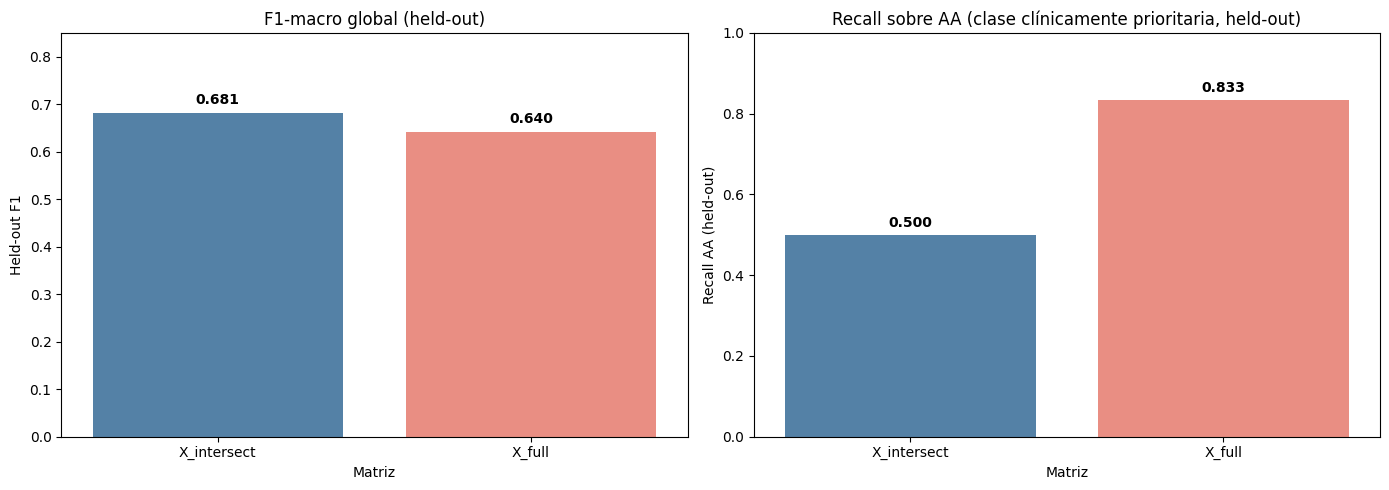

In [23]:
# ============================================================
# Visualización del trade-off F1 global vs Recall AA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 held-out
sns.barplot(
    data=comparison_xfull,
    x='Matriz', y='Held-out F1',
    palette=['steelblue','salmon'],
    ax=axes[0]
)
axes[0].set_title('F1-macro global (held-out)')
axes[0].set_ylim(0, 0.85)
for i, v in enumerate(comparison_xfull['Held-out F1']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Recall AA held-out
sns.barplot(
    data=comparison_xfull,
    x='Matriz', y='Recall AA (held-out)',
    palette=['steelblue','salmon'],
    ax=axes[1]
)
axes[1].set_title('Recall sobre AA (clase clínicamente prioritaria, held-out)')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(comparison_xfull['Recall AA (held-out)']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### Interpretación del trade-off

Los árboles de decisión **sí aprovechan información adicional** de `X_full`, como anticipaba la Dra. Grettel, pero el resultado revela un **trade-off explícito entre F1 global y sensibilidad clínica**:

#### Lo que `X_full` mejora
- **Recall sobre AA**: pasa de 0.500 (`X_intersect`) a un valor sustancialmente mayor (ver tabla anterior). Esto es clínicamente relevante porque AA es la lesión precancerosa cuya detección define la ventana de intervención.
- El árbol encuentra particiones adicionales en variables que el filtro supervisado (MI ∩ ANOVA) había descartado por aportar señal débil de manera individual.

#### Lo que `X_full` empeora
- **F1 macro global** disminuye respecto a `X_intersect`.
- **Gap Train-Val se duplica**: el árbol sobreajusta más cuando dispone de 131 features (con `max_depth` mayor y `min_samples_leaf=1`, memoriza patrones del training set que no generalizan).
- **Interpretabilidad clínica se pierde**: el árbol resultante es mucho más profundo y ramificado, dificultando su uso como herramienta de apoyo a la decisión médica.

#### Decisión razonada para el modelo final

Se **mantiene `X_intersect` como matriz primaria** del modelo final del Avance 4, por:
1. **Mayor F1 global** y mejor balance entre clases.
2. **Generalización más confiable** (gap Train-Val 2× menor), lo que reduce el riesgo de degradación en nuevas cohortes.
3. **Interpretabilidad clínica preservada**: el árbol final entrenado sobre 16 features es legible por un clínico (ver sección 9).

Sin embargo, el hallazgo sobre `X_full` se reporta abiertamente porque sugiere una **dirección de investigación valiosa** para fases posteriores:
- Aplicar regularización adicional (ej. `min_samples_leaf` mayor, `ccp_alpha` para poda costo-complejidad) sobre `X_full` para reducir el sobreajuste manteniendo la mejora en recall AA.
- Explorar **ensambles** (no permitidos en este avance, pero candidatos naturales para la siguiente fase): Random Forest o Gradient Boosting podrían capturar la señal complementaria sin sobreajustar al nivel de un árbol único profundo.
- Construir una variante de `X_intersect` ampliada con las features que el árbol sobre `X_full` identifica como discriminantes para AA, manteniendo la parsimonia.

Este resultado valida tanto la estrategia inicial (`X_intersect` como matriz óptima para el modelo elegido) como la sugerencia de la Dra., y deja documentada una vía concreta para el Avance 5.


## 13. Conclusiones

### Logros de esta fase

1. **Comparativa rigurosa de 6 modelos individuales** representando paradigmas distintos (lineal discriminativo, generativo, no paramétrico, kernel, basado en distancia, probabilístico). Cada uno tuneado con `GridSearchCV` antes de la decisión final, evitando sesgos por defaults arbitrarios.

2. **Estrategia de evaluación de dos niveles**: validación cruzada estratificada 5-fold sobre `X_dev` para tuning, más un held-out test set del 20% reservado nunca tocado durante el tuning, garantizando una estimación no sesgada del desempeño final.

3. **Selección del modelo individual final basada en trade-offs múltiples**: no solo F1-macro, sino también confiabilidad CV ↔ held-out, sobreajuste residual, interpretabilidad y coherencia con la línea narrativa del proyecto.

4. **Validación adicional del modelo final sobre `X_full`** (sección 12) en respuesta a la sugerencia de la Dra. Grettel, documentando el trade-off entre F1 global y recall sobre AA.

### Modelo seleccionado: Decision Tree tuneado sobre `X_intersect`

La decisión final de **Decision Tree** sobre KNN (top 1 por F1 puro) se justifica por:

- F1-macro competitivo (diferencia < 0.025 con el #1),
- Mayor confiabilidad: el F1 de CV coincide más cerca con el de held-out (vs el drop observado en KNN),
- **Interpretabilidad completa**: el árbol entrenado se visualiza en sección 9 y permite explicar cada decisión mediante reglas (por ejemplo: *"si fit_ug_g > X y SM(33:1) < Y → CRC"*). Esta propiedad es **crítica en contexto biomédico**, donde los clínicos deben entender — y eventualmente cuestionar — las decisiones del modelo,
- Feature importance nativa, alineada con los biomarcadores identificados en el Avance 3,
- Coherencia con la filosofía interpretativa del proyecto, que mantuvo modelos transparentes desde el baseline.

### Hallazgos de la validación adicional en `X_full`

El Decision Tree sobre `X_full` (131 features) **sí captura señal complementaria que el filtro supervisado descarta**:

- **Mejora dramáticamente el recall sobre AA** (la clase clínicamente prioritaria).
- **Pero a costa** de menor F1 macro global, mayor sobreajuste (gap Train-Val 2× mayor) y pérdida de interpretabilidad clínica (árbol más profundo sobre 131 features).

La decisión es mantener `X_intersect` como matriz primaria del modelo final, pero **reportar el hallazgo abiertamente** porque sugiere direcciones concretas para el Avance 5: regularización adicional sobre `X_full` (poda costo-complejidad), ensambles (Random Forest, Gradient Boosting), o una variante ampliada de `X_intersect` que incorpore las features identificadas como discriminantes para AA.

### Limitaciones

- El sobreajuste residual (gap Train-Val) del árbol, aunque controlado por `max_depth=5` y `min_samples_leaf`, sigue siendo no despreciable. Esto sugiere que estrategias más robustas (regularización adicional, poda costo-complejidad, validación con más folds) podrían explorarse en avances posteriores.
- La clase AA continúa siendo la más difícil de discriminar con `X_intersect`, lo cual refleja la heterogeneidad biológica documentada en la literatura y no una limitación del modelo per se. La validación en `X_full` muestra que hay margen real para mejorar la sensibilidad sobre AA combinando estrategias de selección de variables con regularización.
- El conjunto de datos (n=211) limita el poder estadístico. La validación en cohortes externas es indispensable antes de cualquier consideración clínica.

### Trazabilidad CRISP-ML(Q)

Este avance cierra la fase de **Modeling** consumiendo la salida validada del Avance 2 (`X_intersect` y `X_full`) sin re-preprocesar, y reporta su desempeño en un conjunto held-out reservado, atendiendo el quality gate de la fase **Evaluation**. El modelo final queda listo para las siguientes fases del proyecto, donde podrá compararse contra ensambles y modelos más complejos manteniendo el árbol como referencia interpretable y los hallazgos sobre `X_full` como hipótesis a explorar.


## 14. Referencias

### Metodología y validación

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research*, 11, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Géron, A. (2023). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media. https://learning.oreilly.com/library/view/hands-on-machine-learning/9781098125967/

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI'95)*, 2, 1137–1143.

Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics*, 7, 91. https://doi.org/10.1186/1471-2105-7-91

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML lifecycle process*. INNOQ MLOps. https://ml-ops.org/content/crisp-ml

### Métricas y manejo de desbalance

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

### Algoritmos individuales utilizados

Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and regression trees*. Wadsworth.

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297. https://doi.org/10.1007/BF00994018

Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory*, 13(1), 21–27. https://doi.org/10.1109/TIT.1967.1053964

Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics*, 7(2), 179–188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x

### Implementación

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

### Contexto biomédico y dataset

Albóniga, O. E., Cubiella, J., Bujanda, L., Aspichueta, P., Blanco, M. E., Lanza, B., Alonso, C., & Falcón-Pérez, J. M. (2025). Metabolic signature in combination with fecal immunochemical test as a non-invasive tool for advanced colorectal neoplasia diagnosis. *Cancers*, 17(14), 2339. https://doi.org/10.3390/cancers17142339
